<a href="https://colab.research.google.com/github/kanchanakanta/git-collaboration-practice/blob/master/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

To design, implement, compile, and train a basic Convolutional Neural Network using TensorFlow/Keras for image classification.

MNIST Dataset
      ↓
Load Dataset
      ↓
Preprocess Images
      ↓
Build CNN
      ↓
Compile Model
      ↓
Train Model
      ↓
Evaluate Model
      ↓
Make Predictions

In [4]:

from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
import numpy as np

In [5]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)


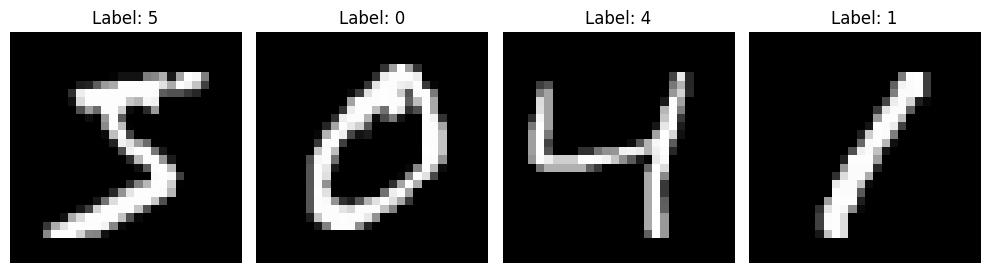

In [6]:
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

plt.figure(figsize=(10, 3))
for i in range(4):
    plt.subplot(1, 4, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

We import TensorFlow and Keras.

TensorFlow → deep learning framework
Keras → high-level API used to easily build neural networks
layers → provides CNN layers such as Conv2D, MaxPooling2D, Dense, etc.

Normalization is the process of scaling input data to a smaller and consistent numerical range before giving it to a neural network.

For the MNIST dataset, each pixel has a value between:

$$ 0 \text{ and } 255 $$

We usually normalize these values to:

0 and 1

In [8]:
X_train = X_train / 255.0
X_test = X_test / 255.0

Add the Channel Dimension


Our image currently has:

$$ 28\times28 $$

But a CNN expects an image in the form:

$$ \boxed{\text{Height}\times\text{Width}\times\text{Channels}} $$

MNIST is a grayscale image, so:

$$ \text{Channels}=1 $$

Therefore:

28×28→28×28×1

In [9]:
X_train = X_train[..., tf.newaxis]
X_test = X_test[..., tf.newaxis]
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)


Training data shape: (60000, 28, 28, 1)
Testing data shape: (10000, 28, 28, 1)


Build the CNN

Now we create the CNN.

In [10]:
model = keras.Sequential([

    layers.Conv2D(32, (3, 3), activation="relu",
                  input_shape=(28, 28, 1)),

    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),

    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(64, activation="relu"),

    layers.Dense(10, activation="softmax")
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [13]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    validation_split=0.1
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 46s 26ms/step - accuracy: 0.7483 - loss: 0.7533 - val_accuracy: 0.9312 - val_loss: 0.2418
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 44s 26ms/step - accuracy: 0.9248 - loss: 0.2497 - val_accuracy: 0.9590 - val_loss: 0.1451
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 45s 26ms/step - accuracy: 0.9514 - loss: 0.1604 - val_accuracy: 0.9633 - val_loss: 0.1222
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 45s 26ms/step - accuracy: 0.9629 - loss: 0.1223 - val_accuracy: 0.9723 - val_loss: 0.0952
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 43s 26ms/step - accuracy: 0.9682 - loss: 0.1032 - val_accuracy: 0.9748 - val_loss: 0.0856


In [14]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9749 - loss: 0.0826
Test Accuracy: 0.9749000072479248


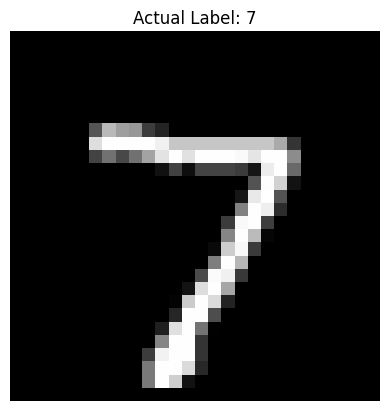

In [15]:
import matplotlib.pyplot as plt

plt.imshow(X_test[0].squeeze(), cmap="gray")
plt.title(f"Actual Label: {y_test[0]}")
plt.axis("off")
plt.show()

In [16]:
image = X_test[0]
image = image.reshape(1, 28, 28, 1)

prediction = model.predict(image)
print(prediction)

predicted_class = prediction.argmax()

print("Predicted Digit:", predicted_class)
print("Actual Digit:", y_test[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
[[7.0106999e-08 3.6897315e-08 1.2757455e-04 5.1042301e-05 6.0710312e-11
  4.2659859e-10 5.9523682e-15 9.9981934e-01 3.3466009e-08 1.9911483e-06]]
Predicted Digit: 7
Actual Digit: 7


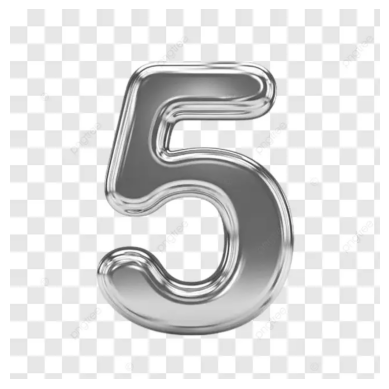

In [19]:
from PIL import Image
img = Image.open("digit5.png")

plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

In [20]:
# Convert to grayscale
img = img.convert("L")

# Resize to 28 × 28
img = img.resize((28, 28))

# Convert to NumPy array
img_array = np.array(img)

print("Shape:", img_array.shape)
print("Minimum:", img_array.min())
print("Maximum:", img_array.max())

Shape: (28, 28)
Minimum: 93
Maximum: 255


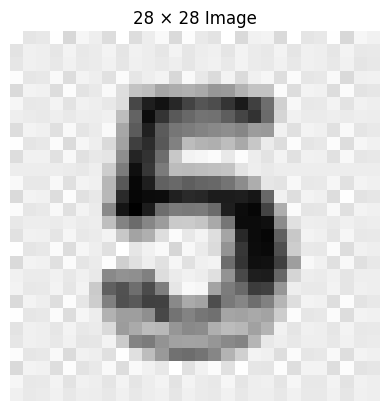

In [21]:
plt.imshow(img_array, cmap="gray")
plt.title("28 × 28 Image")
plt.axis("off")
plt.show()

In [22]:
img_array = img_array / 255.0

In [23]:
img_array = 1.0 - img_array

In [24]:
img_array = img_array.reshape(1, 28, 28, 1)

print("CNN input shape:", img_array.shape)


CNN input shape: (1, 28, 28, 1)


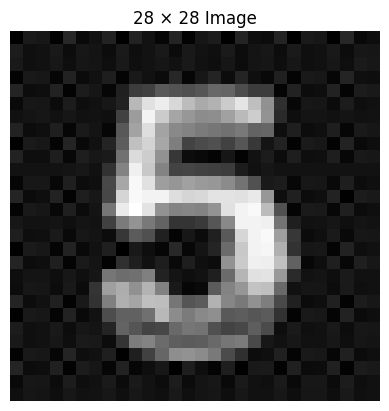

In [28]:

# Display
plt.imshow(img_array.squeeze(), cmap="gray")
plt.title("28 × 28 Image")
plt.axis("off")
plt.show()

In [29]:
prediction = model.predict(img_array, verbose=0)

predicted_digit = prediction.argmax()

print("Predicted Digit:", predicted_digit)

Predicted Digit: 5
